In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

original_df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')
encoded_data = pd.read_csv("../data/proccessed/finish-unsupervised.csv")
encoded_data['Churn'] = original_df['Churn'].map({'Yes': 1, 'No': 0})
encoded_data.to_csv('../data/proccessed/telco_prepared_for_supervised.csv', index=False)


XGBoost Accuracy: 0.8034

XGBoost Classification Report:
              precision    recall  f1-score   support

No Churn (0)       0.84      0.91      0.87      1035
   Churn (1)       0.67      0.50      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



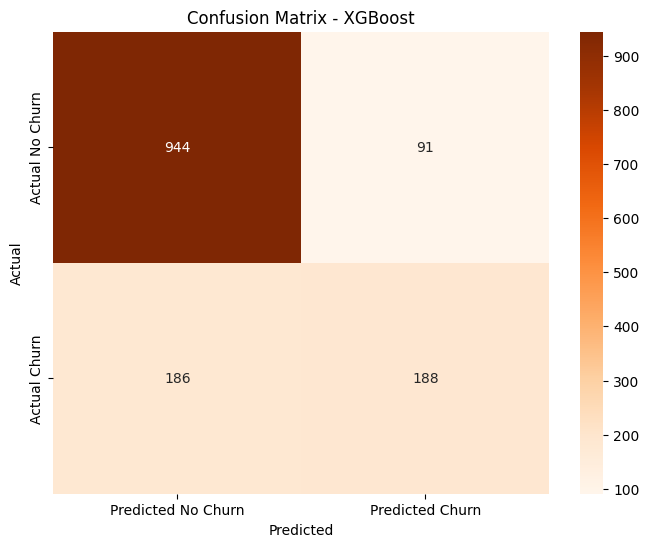

XGBoost ROC-AUC Score: 0.8477


--- Classification Report (Threshold = 0.24) ---
              precision    recall  f1-score   support

No Churn (0)       0.92      0.70      0.79      1035
   Churn (1)       0.50      0.83      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.73      0.75      1409



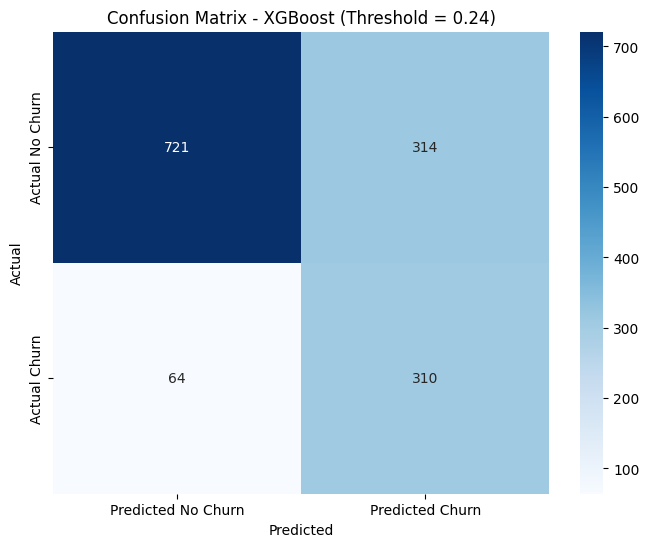

In [14]:

import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    roc_auc_score,
    roc_curve
)
df = pd.read_csv('../data/proccessed/telco_prepared_for_supervised.csv')
X = df.drop("Churn" , axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
xgb_model = xgb.XGBClassifier(n_estimators=300 ,max_depth=3 , learning_rate=0.018873805653130352,subsample=0.623482647376846,colsample_bytree =0.7744474074769765, eval_metric='logloss', random_state=42)

xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}\n")
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn (0)', 'Churn (1)']))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Predicted No Churn', 'Predicted Churn'], 
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"XGBoost ROC-AUC Score: {auc_xgb:.4f}\n")
new_threshold = 0.24
y_pred_new_threshold = (y_pred_proba_xgb >= new_threshold).astype(int)
print(f"\n--- Classification Report (Threshold = {new_threshold}) ---")
print(classification_report(y_test, y_pred_new_threshold, target_names=['No Churn (0)', 'Churn (1)']))
cm_new = confusion_matrix(y_test, y_pred_new_threshold)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted No Churn', 'Predicted Churn'], 
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title(f'Confusion Matrix - XGBoost (Threshold = {new_threshold})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()




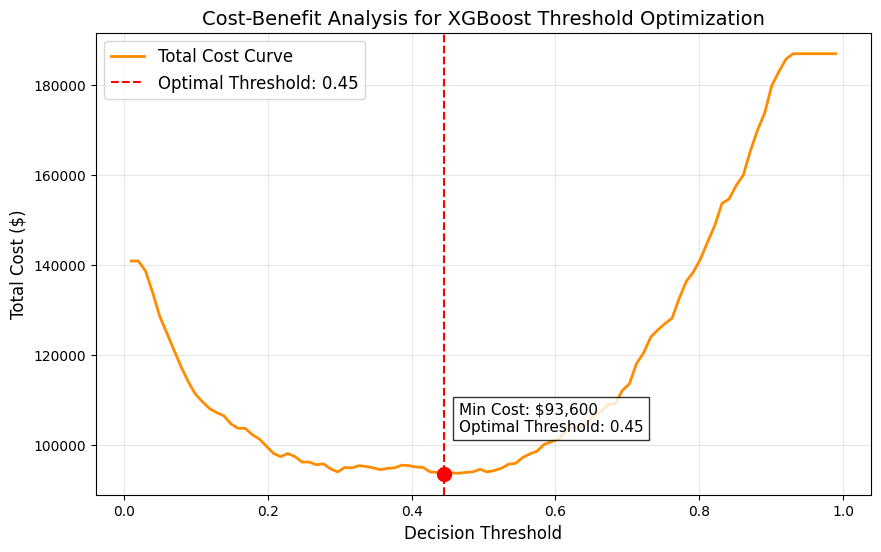

✅ XGBoost: 0.45
✅: $93,600


In [10]:
import numpy as np

def optimize_threshold_by_cost_xgb(y_true, y_probs, cost_FP=100, cost_FN=500, cost_TP=100, cost_TN=0):
    thresholds = np.linspace(0.01, 0.99, 100)
    costs = []

    for thresh in thresholds:
        y_pred = (y_probs >= thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        total_cost = (fp * cost_FP) + (fn * cost_FN) + (tp * cost_TP) + (tn * cost_TN)
        costs.append(total_cost)

    min_cost = min(costs)
    optimal_threshold = thresholds[costs.index(min_cost)]

    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, costs, linewidth=2, color='darkorange', label='Total Cost Curve') # رنگ نارنجی برای تفاوت
    
    plt.axvline(x=optimal_threshold, color='red', linestyle='--', 
                label=f'Optimal Threshold: {optimal_threshold:.2f}')
    plt.scatter(optimal_threshold, min_cost, color='red', s=100, zorder=5)
    
    plt.title('Cost-Benefit Analysis for XGBoost Threshold Optimization', fontsize=14)
    plt.xlabel('Decision Threshold', fontsize=12)
    plt.ylabel('Total Cost ($)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    
    plt.text(optimal_threshold + 0.02, min_cost + (max(costs)*0.05), 
             f'Min Cost: ${min_cost:,.0f}\nOptimal Threshold: {optimal_threshold:.2f}', 
             fontsize=11, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.show()
    
    print(f"✅ XGBoost: {optimal_threshold:.2f}")
    print(f"✅: ${min_cost:,.0f}")
    
    return optimal_threshold

optimal_thresh_xgb = optimize_threshold_by_cost_xgb(y_test, y_pred_proba_xgb)


In [6]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
import xgboost as xgb
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': ratio, 
        'eval_metric': 'logloss',
        'random_state': 42
    }
    
    model = xgb.XGBClassifier(**params)
    score = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc').mean()
    return score

print("Starting Optuna optimization for XGBoost...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=200)

print(f"\nBest XGBoost Params: {study_xgb.best_params}")
print(f"Best XGBoost ROC-AUC: {study_xgb.best_value:.4f}")

[I 2026-05-19 23:52:06,913] A new study created in memory with name: no-name-95c96d58-7dbb-4e67-afb4-fa4ff514878a


Starting Optuna optimization for XGBoost...


[I 2026-05-19 23:52:10,211] Trial 0 finished with value: 0.8232581061855571 and parameters: {'n_estimators': 400, 'max_depth': 10, 'learning_rate': 0.03724411050393307, 'subsample': 0.8005543818275143, 'colsample_bytree': 0.936912104341375}. Best is trial 0 with value: 0.8232581061855571.
[I 2026-05-19 23:52:12,548] Trial 1 finished with value: 0.8385484531941081 and parameters: {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.02180791029003854, 'subsample': 0.61577766278886, 'colsample_bytree': 0.913728363473182}. Best is trial 1 with value: 0.8385484531941081.
[I 2026-05-19 23:52:13,127] Trial 2 finished with value: 0.8407274775473083 and parameters: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05795127708294258, 'subsample': 0.8260132049789624, 'colsample_bytree': 0.7402941102447924}. Best is trial 2 with value: 0.8407274775473083.
[I 2026-05-19 23:52:14,964] Trial 3 finished with value: 0.816237885170278 and parameters: {'n_estimators': 400, 'max_depth': 6, 'lea


Best XGBoost Params: {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.018059300099890683, 'subsample': 0.6754297591439874, 'colsample_bytree': 0.6165512357909312}
Best XGBoost ROC-AUC: 0.8493


[I 2026-05-19 23:55:56,735] A new study created in memory with name: no-name-02339fa9-4501-4e72-950f-b6b4ef91edfd


Starting Optuna optimization for XGBoost (No Data Leakage)...


[I 2026-05-19 23:55:58,539] Trial 0 finished with value: 0.8066379751488659 and parameters: {'n_estimators': 400, 'max_depth': 9, 'learning_rate': 0.19854040968978376, 'subsample': 0.7664362685426107, 'colsample_bytree': 0.9662489732951305}. Best is trial 0 with value: 0.8066379751488659.
[I 2026-05-19 23:55:59,482] Trial 1 finished with value: 0.811560135152309 and parameters: {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1641873557425658, 'subsample': 0.6417822332723739, 'colsample_bytree': 0.8617952710719288}. Best is trial 1 with value: 0.811560135152309.
[I 2026-05-19 23:55:59,770] Trial 2 finished with value: 0.8308619591587156 and parameters: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.08877398109616813, 'subsample': 0.8889109108598201, 'colsample_bytree': 0.877338919952684}. Best is trial 2 with value: 0.8308619591587156.
[I 2026-05-19 23:56:00,562] Trial 3 finished with value: 0.8317819343446626 and parameters: {'n_estimators': 100, 'max_depth': 7, 'lea


✅ Best XGBoost Params: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.016210353937350173, 'subsample': 0.6133893310069771, 'colsample_bytree': 0.7932331651701875}
✅ Best XGBoost ROC-AUC (CV Mean): 0.8484
✅ Model Stability (CV Std): 0.0115

🚀 Final Held-Out Test ROC-AUC: 0.8479

--- Final Classification Report (Threshold = 0.23) ---
              precision    recall  f1-score   support

No Churn (0)       0.97      0.48      0.64      1035
   Churn (1)       0.40      0.95      0.56       374

    accuracy                           0.61      1409
   macro avg       0.68      0.72      0.60      1409
weighted avg       0.82      0.61      0.62      1409



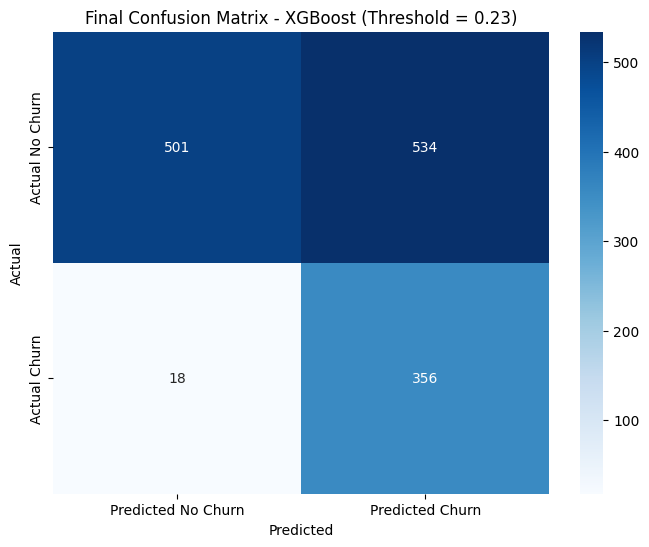

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/proccessed/telco_prepared_for_supervised.csv')
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': ratio, 
        'eval_metric': 'logloss',
        'random_state': 42
    }
    

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', xgb.XGBClassifier(**params))
    ])
    

    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    trial.set_user_attr("std_dev", scores.std())
    
    return scores.mean()

print("Starting Optuna optimization for XGBoost (No Data Leakage)...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50)

print(f"\n✅ Best XGBoost Params: {study_xgb.best_params}")
print(f"✅ Best XGBoost ROC-AUC (CV Mean): {study_xgb.best_value:.4f}")
print(f"✅ Model Stability (CV Std): {study_xgb.best_trial.user_attrs['std_dev']:.4f}")

best_params = study_xgb.best_params
best_params['scale_pos_weight'] = ratio
best_params['eval_metric'] = 'logloss'
best_params['random_state'] = 42

final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBClassifier(**best_params))
])

final_pipeline.fit(X_train, y_train)

y_pred_xgb = final_pipeline.predict(X_test)
y_pred_proba_xgb = final_pipeline.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"\n🚀 Final Held-Out Test ROC-AUC: {auc_xgb:.4f}\n")

new_threshold = 0.23
y_pred_new_threshold = (y_pred_proba_xgb >= new_threshold).astype(int)

print(f"--- Final Classification Report (Threshold = {new_threshold}) ---")
print(classification_report(y_test, y_pred_new_threshold, target_names=['No Churn (0)', 'Churn (1)']))

cm_new = confusion_matrix(y_test, y_pred_new_threshold)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted No Churn', 'Predicted Churn'], 
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title(f'Final Confusion Matrix - XGBoost (Threshold = {new_threshold})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


/var/folders/33/1_9c8vl1123ffv0k7k3c_44c0000gn/T/ipykernel_24460/3134825919.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=xgb_feature_imp_df.head(10), palette='viridis')


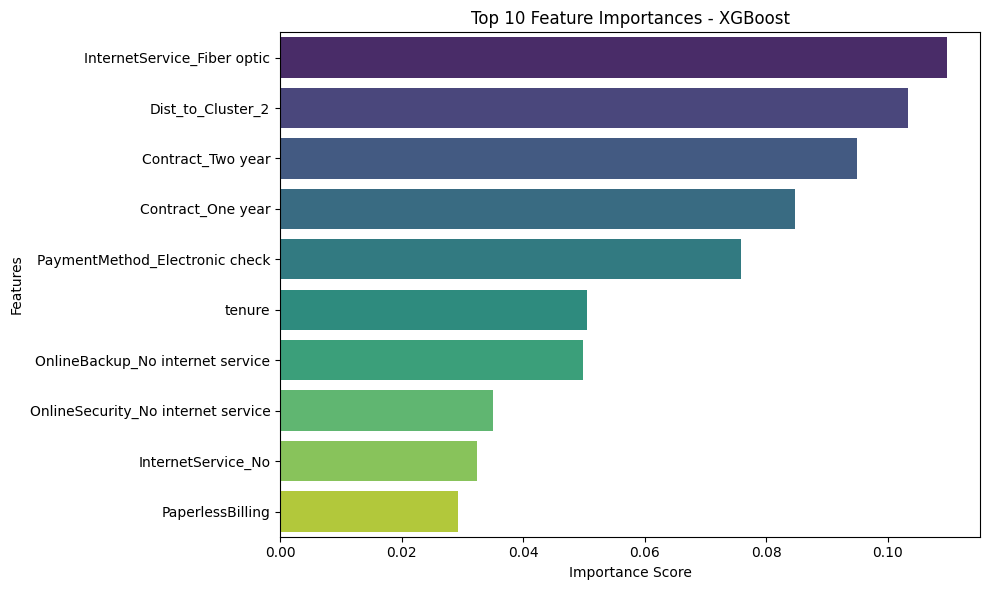

Top 10 Important Features (XGBoost):
                               Feature  Importance
11         InternetService_Fiber optic    0.109667
34                   Dist_to_Cluster_2    0.103304
26                   Contract_Two year    0.094991
25                   Contract_One year    0.084675
28      PaymentMethod_Electronic check    0.075762
4                               tenure    0.050514
15    OnlineBackup_No internet service    0.049842
13  OnlineSecurity_No internet service    0.034983
12                  InternetService_No    0.032397
6                     PaperlessBilling    0.029268


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


xgb_importances = xgb_model.feature_importances_

xgb_feature_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=xgb_feature_imp_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances - XGBoost')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print("Top 10 Important Features (XGBoost):")
print(xgb_feature_imp_df.head(10))


--- SHAP Summary Plot ---


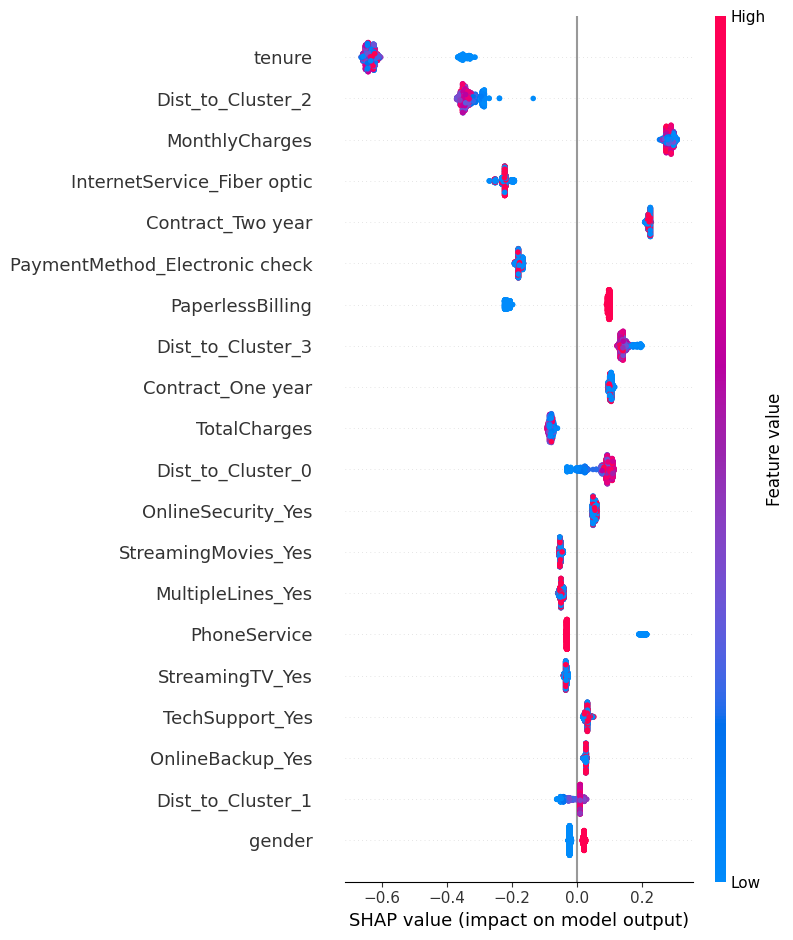


--- SHAP Waterfall Plot (Local Explanation for Customer Index 0) ---


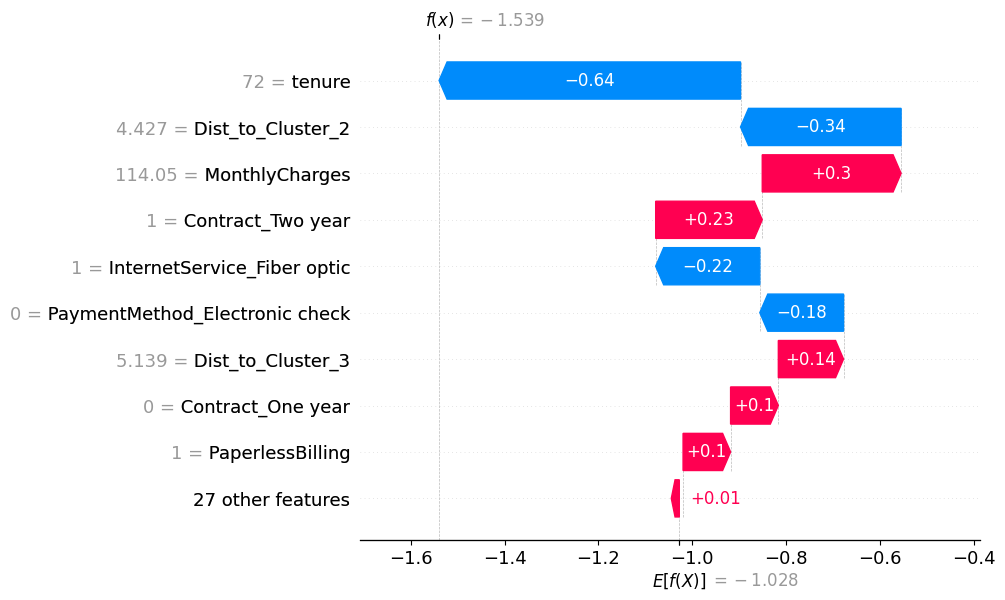

In [7]:
import shap
shap.initjs()
explainer = shap.TreeExplainer(xgb_model) 
X_test_df = pd.DataFrame(X_test, columns=X_train.columns)
shap_values = explainer(X_test_df)
print("--- SHAP Summary Plot ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_df)
print("\n--- SHAP Waterfall Plot (Local Explanation for Customer Index 0) ---")
plt.figure(figsize=(8, 5))
shap.plots.waterfall(shap_values[0])

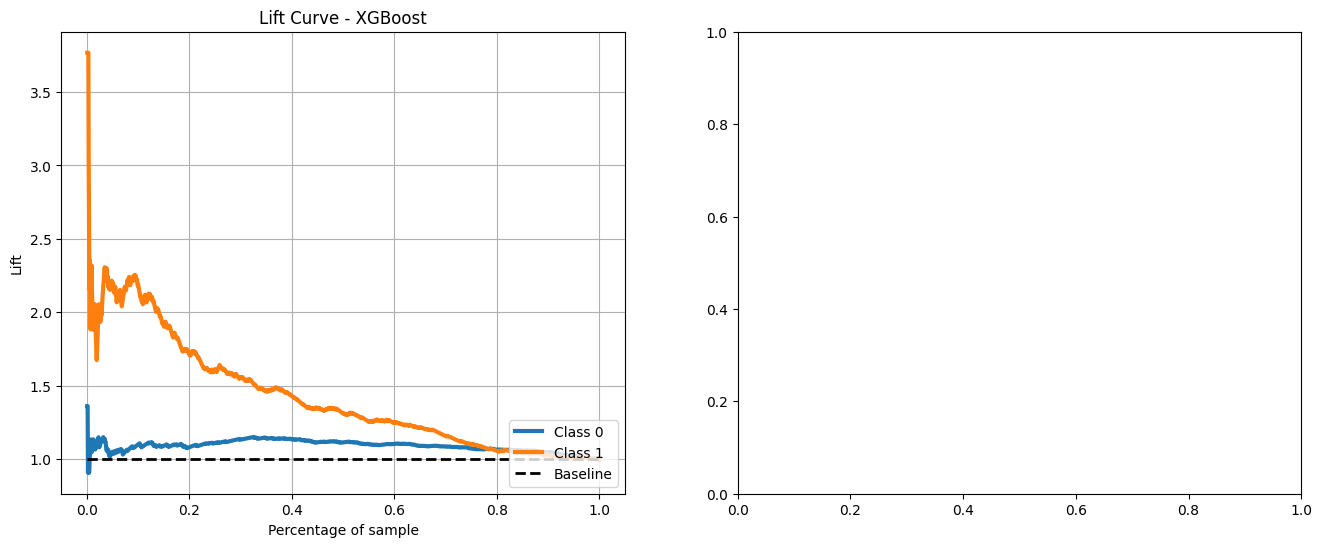

In [ ]:
import numpy as np
import scipy
scipy.interp = np.interp 
import scikitplot as skplt
import matplotlib.pyplot as plt
probas_xgb = xgb_model.predict_proba(X_test)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

skplt.metrics.plot_lift_curve(y_test, probas_xgb, ax=ax[0], title="Lift Curve - XGBoost")

plt.show()
